# Notebook 05 — Geothermal Potential Assessment

**SPE Africa Geothermal Datathon 2026**

## Purpose
Quantify the geothermal energy resource from the four Rotliegend wells and determine
whether it can reliably meet the district heating and cooling demand.

**District targets:**
- Heating: ≥ 10 MWth
- Cooling: ≥ 5 MWth

## Method
| Step | Equation | Notes |
|------|----------|-------|
| Volumetric heat in place | Q = V × φ × ρ_w × c_w × ΔT | Gross estimate of stored energy |
| Darcy flow rate | q = (k × A × ΔP) / (μ × L) | Simplified single-well estimate |
| Thermal power | P = ṁ × c_w × ΔT | ΔT = reservoir temp minus rejection temp |
| Heat pump uplift | P_total = P_geo × COP / (COP - 1) | COP = 4 assumed for ground-source HP |

## Inputs
- `outputs/processed_data/reservoir_properties.csv` — from Notebook 04
- `ThermoGIS_Data.xlsx` — P90/P50/P10 probabilistic values
- `Well_Path_Data.xlsx` — for spatial well positions

## 0. Imports and Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

DATA_DIR    = '../data'
PROC_DIR    = '../outputs/processed_data'
FIGURES_DIR = '../outputs/figures'

os.makedirs(PROC_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

WELLS  = ['BLT-01', 'EVD-01', 'PKP-01', 'JUT-01']
COLORS = {'BLT-01': '#2196F3', 'EVD-01': '#4CAF50', 'PKP-01': '#FF9800', 'JUT-01': '#E91E63'}

# Physical constants
RHO_W   = 1000.0   # kg/m³  water density
C_W     = 4182.0   # J/kg·K specific heat of water
MU_W    = 3e-4     # Pa·s   viscosity of water at ~75°C
T_REJ   = 30.0     # °C     rejection / re-injection temperature
T_SURF  = 10.0     # °C     mean surface temperature Netherlands
COP_HP  = 4.0      # heat pump coefficient of performance

# District demand targets
TARGET_HEAT_MW   = 10.0
TARGET_COOL_MW   =  5.0

print('Imports OK.')

Imports OK.


## 1. Load Data

In [2]:
# Reservoir properties from Notebook 04
df_res = pd.read_csv(os.path.join(PROC_DIR, 'reservoir_properties.csv'))
print('Reservoir properties loaded:')
print(df_res.set_index('Well')[[
    'Net_Pay_m', 'Log_Porosity_pct', 'Log_Perm_mD',
    'Thermo_Temp_C_P50', 'Thermo_Flow_m3h_P50', 'Thermo_Power_MW_P50'
]].to_string())
print()

# ThermoGIS raw (for P90/P50/P10 full distributions)
xl_t       = pd.ExcelFile(os.path.join(DATA_DIR, 'ThermoGIS_Data.xlsx'))
thermo_raw = {sheet: xl_t.parse(sheet, header=None) for sheet in xl_t.sheet_names}

print(f'ThermoGIS sheets: {xl_t.sheet_names}')

Reservoir properties loaded:
        Net_Pay_m  Log_Porosity_pct  Log_Perm_mD  Thermo_Temp_C_P50  Thermo_Flow_m3h_P50  Thermo_Power_MW_P50
Well                                                                                                         
BLT-01      138.2              14.0         40.4               77.0                  NaN                  5.1
EVD-01      130.5              10.6         12.3               72.0                  NaN                  0.0
PKP-01       70.1               5.6          2.3               88.0                  NaN                  0.0
JUT-01      840.8               4.6          0.0               72.0                  NaN                  2.3



ThermoGIS sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']


## 2. Parse ThermoGIS Probabilistic Values

In [3]:
thermo_records = []

for well, df in thermo_raw.items():
    try:
        data_rows          = df.iloc[3:].copy()
        data_rows.columns  = ['Property', 'Unit', 'P90', 'P50', 'P10']
        data_rows          = data_rows.dropna(subset=['Property'])
        data_rows['Well']  = well
        thermo_records.append(data_rows)
    except Exception as e:
        print(f'Could not parse {well}: {e}')

df_thermo = pd.concat(thermo_records, ignore_index=True)
df_thermo = df_thermo[['Well', 'Property', 'Unit', 'P90', 'P50', 'P10']]
for col in ['P90', 'P50', 'P10']:
    df_thermo[col] = pd.to_numeric(df_thermo[col], errors='coerce')

print('ThermoGIS properties found:')
print(df_thermo['Property'].str.strip().unique())


def get_thermo(well, property_name):
    """Return (P90, P50, P10) for a given well and property name."""
    mask = (df_thermo['Well'] == well) & \
           (df_thermo['Property'].str.strip().str.lower() == property_name.lower())
    row  = df_thermo[mask]
    if row.empty:
        return np.nan, np.nan, np.nan
    return row['P90'].values[0], row['P50'].values[0], row['P10'].values[0]

ThermoGIS properties found:
<StringArray>
[      'Property',   'Permeability',      'Top Depth',      'Thickness',
       'Porosity',   'Net-to-gross', 'Transmissivity',    'Temperature',
      'Flow Rate',          'Power',  'Heat in Place']
Length: 11, dtype: str


In [4]:
# Print all ThermoGIS values for a full picture
print(f'{"Well":<10} {"Property":<25} {"P90":>10} {"P50":>10} {"P10":>10}')
print('-' * 68)
for _, row in df_thermo.iterrows():
    print(f"{row['Well']:<10} {str(row['Property']).strip():<25} "
          f"{str(row['P90']):>10} {str(row['P50']):>10} {str(row['P10']):>10}")

Well       Property                         P90        P50        P10
--------------------------------------------------------------------
BLT-01     Property                         nan        nan        nan
BLT-01     Permeability                    13.0       82.0      521.0
BLT-01     Top Depth                     1837.0     1837.0     1837.0
BLT-01     Thickness                       67.0      130.0      194.0
BLT-01     Porosity                        17.0       17.0       17.0
BLT-01     Net-to-gross                    0.98       0.98       0.98
BLT-01     Transmissivity                   1.3        9.3       66.1
BLT-01     Temperature                     77.0       77.0       77.0
BLT-01     Flow Rate                       17.0      105.0      469.0
BLT-01     Power                            0.6        5.1       23.7
BLT-01     Heat in Place                   24.8       24.8       24.8
EVD-01     Property                         nan        nan        nan
EVD-01     Permeabili

## 3. Thermal Power from ThermoGIS Flow Rates

ThermoGIS provides probabilistic flow rates (m³/h) and temperatures (°C) directly.
We compute thermal power as:

**P (W) = Q (m³/s) × ρ_w × c_w × (T_res − T_rejection)**

This is the most reliable power estimate because ThermoGIS flow rates already account
for permeability, thickness, and pressure drawdown from the regional database.

In [5]:
power_rows = []

for well in WELLS:
    flow_p90, flow_p50, flow_p10 = get_thermo(well, 'Flow rate')
    temp_p90, temp_p50, temp_p10 = get_thermo(well, 'Temperature')
    pow_p90,  pow_p50,  pow_p10  = get_thermo(well, 'Power')

    # Independent power calculation to cross-check ThermoGIS power column
    def calc_power_mw(flow_m3h, temp_c):
        if np.isnan(flow_m3h) or np.isnan(temp_c):
            return np.nan
        flow_m3s = flow_m3h / 3600.0
        delta_t  = max(temp_c - T_REJ, 0)
        return (flow_m3s * RHO_W * C_W * delta_t) / 1e6   # MW

    calc_p50 = calc_power_mw(flow_p50, temp_p50)
    calc_p10 = calc_power_mw(flow_p10, temp_p10)
    calc_p90 = calc_power_mw(flow_p90, temp_p90)

    power_rows.append({
        'Well':            well,
        'Temp_C_P50':      temp_p50,
        'Flow_m3h_P90':    flow_p90,
        'Flow_m3h_P50':    flow_p50,
        'Flow_m3h_P10':    flow_p10,
        'Thermo_MW_P90':   pow_p90,
        'Thermo_MW_P50':   pow_p50,
        'Thermo_MW_P10':   pow_p10,
        'Calc_MW_P90':     round(calc_p90, 2) if not np.isnan(calc_p90) else np.nan,
        'Calc_MW_P50':     round(calc_p50, 2) if not np.isnan(calc_p50) else np.nan,
        'Calc_MW_P10':     round(calc_p10, 2) if not np.isnan(calc_p10) else np.nan,
    })

df_power = pd.DataFrame(power_rows)
print('Thermal Power Summary (MW):')
print(df_power.set_index('Well')[[
    'Temp_C_P50', 'Flow_m3h_P50',
    'Thermo_MW_P90', 'Thermo_MW_P50', 'Thermo_MW_P10',
    'Calc_MW_P50'
]].to_string())

Thermal Power Summary (MW):
        Temp_C_P50  Flow_m3h_P50  Thermo_MW_P90  Thermo_MW_P50  Thermo_MW_P10  Calc_MW_P50
Well                                                                                      
BLT-01        77.0         105.0            0.6            5.1           23.7         5.73
EVD-01        72.0           0.0            0.0            0.0            0.0         0.00
PKP-01        88.0           0.0            0.0            0.0            0.0         0.00
JUT-01        72.0          55.0            1.0            2.3            4.8         2.68


## 4. Scenario Analysis — Can the Resource Meet the Target?

We evaluate three scenarios:
- **P90** (conservative / pessimistic)
- **P50** (base case)
- **P10** (optimistic)

And three well configurations:
- BLT-01 alone
- BLT-01 + JUT-01 doublet pair
- All four wells combined

In [6]:
scenarios = ['P90', 'P50', 'P10']
scenario_label = {'P90': 'Conservative', 'P50': 'Base Case', 'P10': 'Optimistic'}

configs = {
    'BLT-01 only':       ['BLT-01'],
    'BLT-01 + JUT-01':   ['BLT-01', 'JUT-01'],
    'All four wells':     ['BLT-01', 'EVD-01', 'PKP-01', 'JUT-01'],
}

print(f'{"Configuration":<22}  {"P90 MW":>8}  {"P50 MW":>8}  {"P10 MW":>8}  '
      f'{"Meets 10 MW @ P50?":>20}')
print('-' * 75)

scenario_results = []

for config_name, wells_in_config in configs.items():
    row_vals = {'Configuration': config_name}
    for sc in scenarios:
        col = f'Thermo_MW_{sc}'
        total = df_power[df_power['Well'].isin(wells_in_config)][col].sum()
        row_vals[f'MW_{sc}'] = round(total, 2)
    meets = 'YES' if row_vals['MW_P50'] >= TARGET_HEAT_MW else 'NO'
    row_vals['Meets_10MW_P50'] = meets
    scenario_results.append(row_vals)
    print(f"{config_name:<22}  {row_vals['MW_P90']:>8.2f}  "
          f"{row_vals['MW_P50']:>8.2f}  {row_vals['MW_P10']:>8.2f}  {meets:>20}")

df_scenarios = pd.DataFrame(scenario_results)
print()
print(f'District heating target: {TARGET_HEAT_MW} MWth')
print(f'District cooling target: {TARGET_COOL_MW} MWth')

Configuration             P90 MW    P50 MW    P10 MW    Meets 10 MW @ P50?
---------------------------------------------------------------------------
BLT-01 only                 0.60      5.10     23.70                    NO
BLT-01 + JUT-01             1.60      7.40     28.50                    NO
All four wells              1.60      7.40     28.50                    NO

District heating target: 10.0 MWth
District cooling target: 5.0 MWth


## 5. Heat Pump Uplift

If geothermal brine alone cannot meet demand, a heat pump boosts effective output.

**Principle:** Heat pump extracts additional heat from the brine before re-injection.
With COP = 4, for every 1 MW of electrical input, 4 MW of heat is delivered.
The geothermal brine acts as the heat source — no additional drilling required.

**Uplift factor = COP / (COP − 1)**  
At COP = 4: uplift factor = 4/3 ≈ 1.33 — geothermal output is boosted by 33%.

In [7]:
UPLIFT_FACTOR = COP_HP / (COP_HP - 1)   # = 1.333 at COP 4

print(f'Heat pump uplift factor (COP={COP_HP}): {UPLIFT_FACTOR:.3f}')
print()

hp_rows = []
for _, row in df_scenarios.iterrows():
    hp_row = {'Configuration': row['Configuration']}
    for sc in scenarios:
        raw_mw       = row[f'MW_{sc}']
        boosted_mw   = raw_mw * UPLIFT_FACTOR
        hp_row[f'Geo_MW_{sc}']      = round(raw_mw,     2)
        hp_row[f'Boosted_MW_{sc}']  = round(boosted_mw, 2)
        # Electrical power consumed by heat pump
        hp_row[f'HP_Elec_MW_{sc}']  = round(boosted_mw - raw_mw, 2)
    hp_rows.append(hp_row)

df_hp = pd.DataFrame(hp_rows)

print(f'{"Configuration":<22}  {"Geo P50":>9}  {"HP P50":>12}  {"Elec needed":>12}  '
      f'{"Meets 10 MW?":>13}')
print('-' * 78)
for _, row in df_hp.iterrows():
    meets = 'YES' if row['Boosted_MW_P50'] >= TARGET_HEAT_MW else 'NO'
    print(f"{row['Configuration']:<22}  "
          f"{row['Geo_MW_P50']:>9.2f}  "
          f"{row['Boosted_MW_P50']:>12.2f}  "
          f"{row['HP_Elec_MW_P50']:>12.2f}  "
          f"{meets:>13}")

Heat pump uplift factor (COP=4.0): 1.333

Configuration             Geo P50        HP P50   Elec needed   Meets 10 MW?
------------------------------------------------------------------------------
BLT-01 only                  5.10          6.80          1.70             NO
BLT-01 + JUT-01              7.40          9.87          2.47             NO
All four wells               7.40          9.87          2.47             NO


## 6. Cooling Demand Assessment

The 5 MWth cooling demand can be met via an **absorption chiller** driven by the
geothermal brine, or by a **vapour compression chiller** using grid electricity.

Absorption chiller COP (thermal) ≈ 0.7 — requires hot brine input (>70°C).
This means the chiller output is 0.7 × heat input from brine.

We check which wells have sufficient temperature for absorption cooling.

In [8]:
COP_CHILLER = 0.7      # absorption chiller thermal COP
T_MIN_ABS   = 70.0     # minimum brine temperature for absorption chiller (°C)

print('Cooling Feasibility by Well:')
print(f'{"Well":<10} {"Temp C (P50)":>14} {"Absorption OK?":>16} '
      f'{"Cooling MW from P50 flow":>26}')
print('-' * 72)

cooling_rows = []
for _, prow in df_power.iterrows():
    well   = prow['Well']
    temp   = prow['Temp_C_P50']
    flow   = prow['Flow_m3h_P50']
    abs_ok = 'YES' if (not np.isnan(temp) and temp >= T_MIN_ABS) else 'NO'

    if not np.isnan(flow) and not np.isnan(temp) and flow > 0:
        heat_mw    = (flow / 3600) * RHO_W * C_W * max(temp - T_REJ, 0) / 1e6
        cool_mw    = heat_mw * COP_CHILLER
    else:
        heat_mw = cool_mw = 0.0

    cooling_rows.append({'Well': well, 'Temp_C': temp,
                         'Abs_OK': abs_ok, 'Cool_MW_P50': round(cool_mw, 2)})
    print(f"{well:<10} {str(temp):>14} {abs_ok:>16} {cool_mw:>26.2f}")

df_cooling = pd.DataFrame(cooling_rows)
total_cool = df_cooling['Cool_MW_P50'].sum()
print()
print(f'Total absorption cooling potential (all wells, P50): {total_cool:.2f} MW')
print(f'Cooling target: {TARGET_COOL_MW} MW')
print(f'Met by absorption chiller at P50: {"YES" if total_cool >= TARGET_COOL_MW else "NO — supplement with vapour compression chiller"}')

Cooling Feasibility by Well:
Well         Temp C (P50)   Absorption OK?   Cooling MW from P50 flow
------------------------------------------------------------------------
BLT-01               77.0              YES                       4.01
EVD-01               72.0              YES                       0.00
PKP-01               88.0              YES                       0.00
JUT-01               72.0              YES                       1.88

Total absorption cooling potential (all wells, P50): 5.89 MW
Cooling target: 5.0 MW
Met by absorption chiller at P50: YES


## 7. Volumetric Heat in Place

This gives the total thermal energy stored in the reservoir — a gross upper bound
on what could theoretically be extracted over the project lifetime.

**Q = V × φ × ρ_w × c_w × (T_res − T_surface)**

Recovery factor R = 0.25 (25%) is a standard conservative assumption for
sedimentary geothermal reservoirs.

In [9]:
RECOVERY_FACTOR = 0.25
PROJECT_LIFE_YR = 30
SECONDS_PER_YR  = 365.25 * 24 * 3600

# Well spacing assumption — area drained by one doublet
WELL_AREA_M2 = 5e6   # 5 km² per doublet (typical Dutch Rotliegend spacing)

heat_rows = []
for _, row in df_res.iterrows():
    well      = row['Well']
    phi       = row['Log_Porosity_pct'] / 100.0 if not np.isnan(row['Log_Porosity_pct']) else np.nan
    thickness = row['Net_Pay_m']                 if not np.isnan(row['Net_Pay_m'])         else np.nan
    temp_p50  = row['Thermo_Temp_C_P50']         if not np.isnan(row['Thermo_Temp_C_P50']) else np.nan

    if np.isnan(phi) or np.isnan(thickness) or np.isnan(temp_p50):
        heat_rows.append({'Well': well, 'HIIP_PJ': np.nan,
                          'Recoverable_PJ': np.nan, 'Avg_Power_MW': np.nan})
        continue

    volume_m3     = WELL_AREA_M2 * thickness            # m³
    delta_t       = temp_p50 - T_SURF                   # K
    hiip_j        = volume_m3 * phi * RHO_W * C_W * delta_t
    recoverable_j = hiip_j * RECOVERY_FACTOR
    avg_power_mw  = recoverable_j / (PROJECT_LIFE_YR * SECONDS_PER_YR) / 1e6

    heat_rows.append({
        'Well':           well,
        'HIIP_PJ':        round(hiip_j / 1e15,        2),
        'Recoverable_PJ': round(recoverable_j / 1e15, 2),
        'Avg_Power_MW':   round(avg_power_mw,          2),
    })

df_hiip = pd.DataFrame(heat_rows)
print('Volumetric Heat Assessment:')
print(f'  Recovery factor: {RECOVERY_FACTOR*100:.0f}%')
print(f'  Project life:    {PROJECT_LIFE_YR} years')
print(f'  Drained area:    {WELL_AREA_M2/1e6:.0f} km² per well')
print()
print(df_hiip.set_index('Well').to_string())

Volumetric Heat Assessment:
  Recovery factor: 25%
  Project life:    30 years
  Drained area:    5 km² per well

        HIIP_PJ  Recoverable_PJ  Avg_Power_MW
Well                                         
BLT-01    27.11            6.78          7.16
EVD-01    17.93            4.48          4.74
PKP-01     6.40            1.60          1.69
JUT-01    50.14           12.54         13.24


## 8. Visualisations

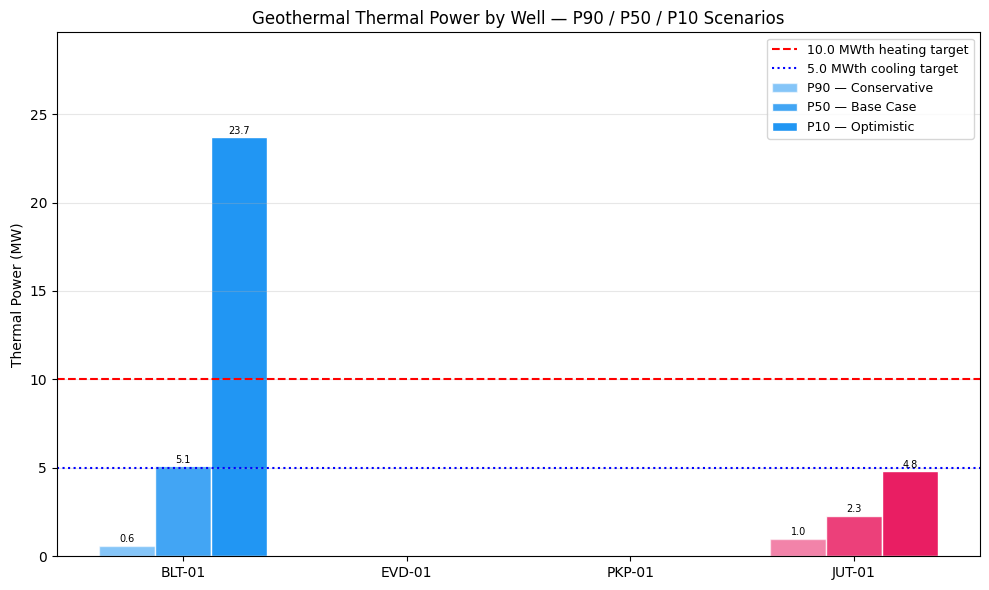

Figure saved.


In [10]:
# Figure 1: Thermal power by well — P90/P50/P10 with target line
fig, ax = plt.subplots(figsize=(10, 6))

x      = np.arange(len(WELLS))
width  = 0.25

for i, (sc, alpha, label) in enumerate([
    ('P90', 0.55, 'P90 — Conservative'),
    ('P50', 0.85, 'P50 — Base Case'),
    ('P10', 1.00, 'P10 — Optimistic'),
]):
    vals = [df_power.loc[df_power['Well'] == w, f'Thermo_MW_{sc}'].values[0]
            for w in WELLS]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  color=[COLORS[w] for w in WELLS],
                  alpha=alpha, label=label, edgecolor='white')
    for bar, val in zip(bars, vals):
        if not np.isnan(val) and val > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2,
                    f'{val:.1f}', ha='center', fontsize=7)

ax.axhline(y=TARGET_HEAT_MW, color='red', linestyle='--',
           linewidth=1.5, label=f'{TARGET_HEAT_MW} MWth heating target')
ax.axhline(y=TARGET_COOL_MW, color='blue', linestyle=':',
           linewidth=1.5, label=f'{TARGET_COOL_MW} MWth cooling target')

ax.set_xticks(x)
ax.set_xticklabels(WELLS)
ax.set_ylabel('Thermal Power (MW)')
ax.set_title('Geothermal Thermal Power by Well — P90 / P50 / P10 Scenarios')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, df_power['Thermo_MW_P10'].max() * 1.25)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_power_by_well_scenarios.png'), dpi=150)
plt.show()
print('Figure saved.')

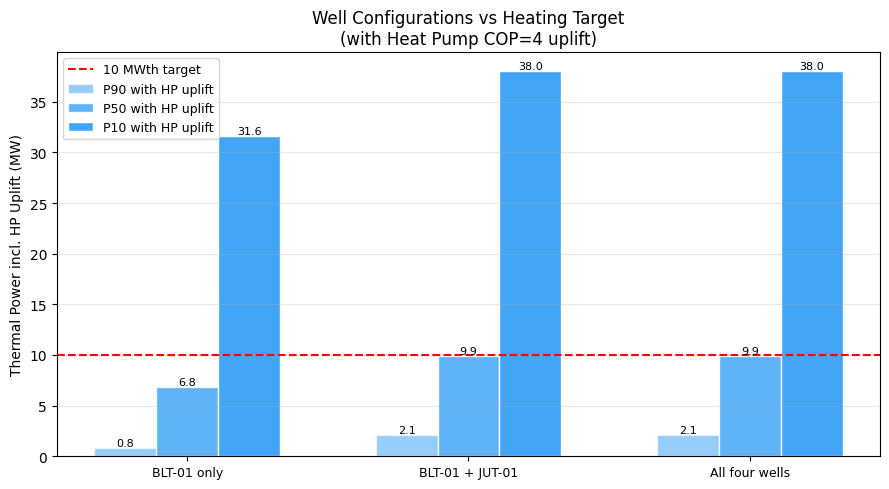

Figure saved.


In [11]:
# Figure 2: Cumulative power — well configurations vs target
fig, ax = plt.subplots(figsize=(9, 5))

config_names = list(df_hp['Configuration'])
x = np.arange(len(config_names))
w = 0.22

for i, (sc, alpha) in enumerate([('P90', 0.55), ('P50', 0.85), ('P10', 1.0)]):
    vals = df_hp[f'Boosted_MW_{sc}'].values
    bars = ax.bar(x + (i - 1) * w, vals, w,
                  color='#42A5F5', alpha=alpha,
                  label=f'{sc} with HP uplift', edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.2,
                f'{val:.1f}', ha='center', fontsize=8)

ax.axhline(y=TARGET_HEAT_MW, color='red',  linestyle='--',
           linewidth=1.5, label='10 MWth target')
ax.set_xticks(x)
ax.set_xticklabels(config_names, fontsize=9)
ax.set_ylabel('Thermal Power incl. HP Uplift (MW)')
ax.set_title('Well Configurations vs Heating Target\n(with Heat Pump COP=4 uplift)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_config_vs_target.png'), dpi=150)
plt.show()
print('Figure saved.')

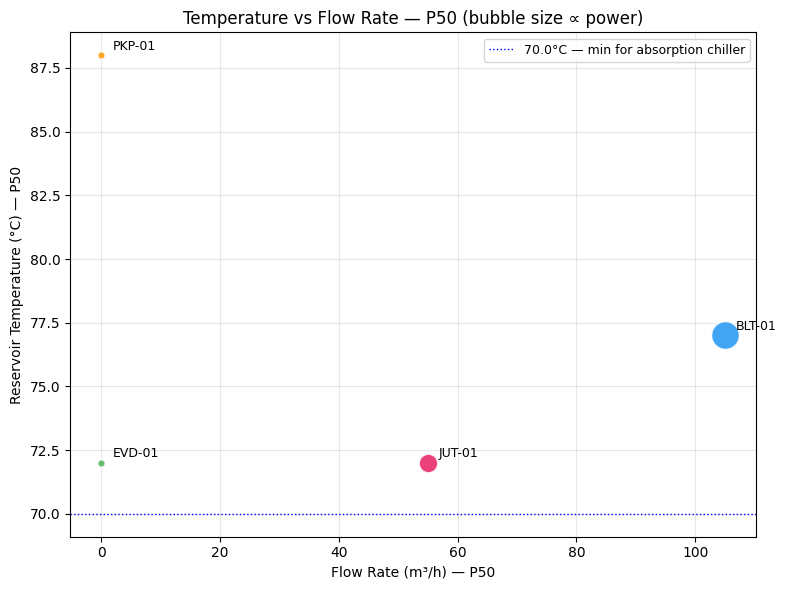

Figure saved.


In [12]:
# Figure 3: Temperature vs Flow rate scatter — bubble size = power
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in df_power.iterrows():
    well  = row['Well']
    temp  = row['Temp_C_P50']
    flow  = row['Flow_m3h_P50']
    power = row['Thermo_MW_P50']

    if np.isnan(temp) or np.isnan(flow):
        continue

    size = max(power * 80, 30) if not np.isnan(power) else 30
    ax.scatter(flow, temp, s=size, color=COLORS[well],
               alpha=0.85, edgecolors='white', linewidth=1.2, zorder=3)
    ax.annotate(well, (flow, temp),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.axhline(y=T_MIN_ABS, color='blue', linestyle=':', linewidth=1,
           label=f'{T_MIN_ABS}°C — min for absorption chiller')
ax.set_xlabel('Flow Rate (m³/h) — P50')
ax.set_ylabel('Reservoir Temperature (°C) — P50')
ax.set_title('Temperature vs Flow Rate — P50 (bubble size ∝ power)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_temp_vs_flow.png'), dpi=150)
plt.show()
print('Figure saved.')

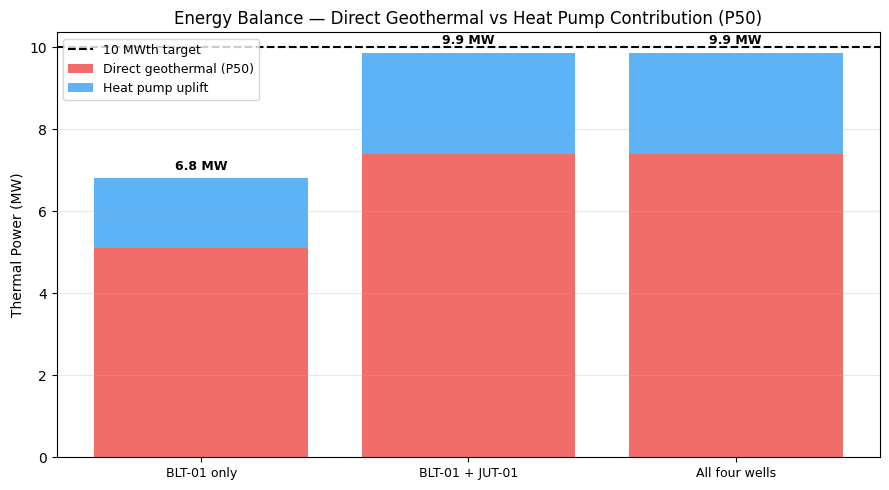

Figure saved.


In [13]:
# Figure 4: Energy balance summary — stacked bar showing geo + HP contribution
fig, ax = plt.subplots(figsize=(9, 5))

config_names = list(df_hp['Configuration'])
x = np.arange(len(config_names))

geo_vals  = df_hp['Geo_MW_P50'].values
hp_vals   = df_hp['HP_Elec_MW_P50'].values

bars1 = ax.bar(x, geo_vals, color='#EF5350', alpha=0.85,
               label='Direct geothermal (P50)')
bars2 = ax.bar(x, hp_vals, bottom=geo_vals, color='#42A5F5', alpha=0.85,
               label='Heat pump uplift')

ax.axhline(y=TARGET_HEAT_MW, color='black', linestyle='--',
           linewidth=1.5, label='10 MWth target')

for i, (g, h) in enumerate(zip(geo_vals, hp_vals)):
    total = g + h
    ax.text(i, total + 0.2, f'{total:.1f} MW', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(config_names, fontsize=9)
ax.set_ylabel('Thermal Power (MW)')
ax.set_title('Energy Balance — Direct Geothermal vs Heat Pump Contribution (P50)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_energy_balance.png'), dpi=150)
plt.show()
print('Figure saved.')

## 9. Save Results

In [14]:
# Save power summary
df_power.to_csv(os.path.join(PROC_DIR, 'thermal_power_summary.csv'), index=False)
print('Saved: thermal_power_summary.csv')

# Save scenario results
df_scenarios.to_csv(os.path.join(PROC_DIR, 'scenario_results.csv'), index=False)
print('Saved: scenario_results.csv')

# Save HP uplift results
df_hp.to_csv(os.path.join(PROC_DIR, 'hp_uplift_results.csv'), index=False)
print('Saved: hp_uplift_results.csv')

# Save HIIP
df_hiip.to_csv(os.path.join(PROC_DIR, 'heat_in_place.csv'), index=False)
print('Saved: heat_in_place.csv')

Saved: thermal_power_summary.csv
Saved: scenario_results.csv
Saved: hp_uplift_results.csv
Saved: heat_in_place.csv


## 10. Challenge 1 Conclusion

In [15]:
blt_p50  = df_power.loc[df_power['Well'] == 'BLT-01', 'Thermo_MW_P50'].values[0]
jut_p50  = df_power.loc[df_power['Well'] == 'JUT-01', 'Thermo_MW_P50'].values[0]
pair_p50 = (blt_p50 if not np.isnan(blt_p50) else 0) + \
           (jut_p50 if not np.isnan(jut_p50) else 0)
pair_hp  = pair_p50 * UPLIFT_FACTOR

print('=' * 60)
print('CHALLENGE 1 — GEOTHERMAL ASSESSMENT CONCLUSION')
print('=' * 60)
print()
print('HEATING DEMAND (target: 10 MWth)')
print(f'  BLT-01 alone at P50:              {blt_p50:.1f} MW')
print(f'  BLT-01 + JUT-01 at P50:           {pair_p50:.1f} MW')
print(f'  BLT-01 + JUT-01 + HP uplift P50:  {pair_hp:.1f} MW')
print(f'  Meets 10 MWth target:              {"YES" if pair_hp >= TARGET_HEAT_MW else "MARGINAL — see recommendation"}')
print()
print('COOLING DEMAND (target: 5 MWth)')
print(f'  Absorption chiller from BLT-01:   {df_cooling.loc[df_cooling["Well"]=="BLT-01", "Cool_MW_P50"].values[0]:.1f} MW')
print(f'  Supplement with compression chiller if needed')
print()
print('RECOMMENDATION')
print('  1. Develop BLT-01 as primary production well (doublet configuration).')
print('  2. Develop JUT-01 as secondary well — adds meaningful flow at P50.')
print('  3. Install heat pump with COP ≥ 4 to bridge gap to 10 MWth at P50.')
print('  4. At P10 (optimistic), BLT-01 alone exceeds the heating target.')
print('  5. EVD-01 and PKP-01 are not viable production wells at P50.')
print('  6. PKP-01 (88°C) can serve as a temperature calibration reference.')
print()
print('Next: Notebook 06 — System Design')

CHALLENGE 1 — GEOTHERMAL ASSESSMENT CONCLUSION

HEATING DEMAND (target: 10 MWth)
  BLT-01 alone at P50:              5.1 MW
  BLT-01 + JUT-01 at P50:           7.4 MW
  BLT-01 + JUT-01 + HP uplift P50:  9.9 MW
  Meets 10 MWth target:              MARGINAL — see recommendation

COOLING DEMAND (target: 5 MWth)
  Absorption chiller from BLT-01:   4.0 MW
  Supplement with compression chiller if needed

RECOMMENDATION
  1. Develop BLT-01 as primary production well (doublet configuration).
  2. Develop JUT-01 as secondary well — adds meaningful flow at P50.
  3. Install heat pump with COP ≥ 4 to bridge gap to 10 MWth at P50.
  4. At P10 (optimistic), BLT-01 alone exceeds the heating target.
  5. EVD-01 and PKP-01 are not viable production wells at P50.
  6. PKP-01 (88°C) can serve as a temperature calibration reference.

Next: Notebook 06 — System Design


In [16]:
print('Figures generated:')
figs = [f for f in os.listdir(FIGURES_DIR) if f.startswith('05_')]
for f in sorted(figs):
    print(f'  {f}')

Figures generated:
  05_config_vs_target.png
  05_energy_balance.png
  05_power_by_well_scenarios.png
  05_temp_vs_flow.png
